# Fake Job Posting Detection — Model Training & Comparative Evaluation

This notebook is the modelling stage of the project pipeline:

> Problem Formulation → Data Preparation → Pre-processing → EDA → **Modelling → Evaluation**

We train three classifiers on TF-IDF features extracted from combined job posting text, then compare them using accuracy, precision, recall, F1, confusion matrices, Precision–Recall curves, and cross-validation. A final model is selected and its most informative features are inspected.

**Models compared**
1. Multinomial Naïve Bayes
2. Logistic Regression
3. Random Forest


---
## 1. Imports & Configuration

All libraries are imported up-front and a global random seed is set for reproducibility.


In [44]:
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    PrecisionRecallDisplay,
)

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

print('All imports successful.')


All imports successful.


---
## 2. Load the Dataset

We reload the raw CSV used in the EDA notebook and confirm its shape.


In [46]:
df = pd.read_csv('merged_job_postings.csv')
print(f'Shape: {df.shape}')
print('Fraud distribution:')
print(df['fraudulent'].value_counts())
df.head(3)


Shape: (17977, 18)
Fraud distribution:
fraudulent
0    17111
1      866
Name: count, dtype: int64


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1.0,Marketing Intern,"US, NY, New York",Marketing,0,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,0,0.0,1.0,0.0,Other,Internship,0,0,Marketing,0
1,2.0,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,0,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0.0,1.0,0.0,Full-time,Not Applicable,0,Marketing and Advertising,Customer Service,0
2,3.0,Commissioning Machinery Assistant (CMA),"US, IA, Wever",0,0,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,0,0.0,1.0,0.0,0,0,0,0,0,0


---
## 3. Pre-processing & Feature Engineering

### 3.1 Text cleaning

We define a cleaning function that:
- Lowercases all text.
- Removes HTML tags (some descriptions contain raw HTML).
- Strips punctuation and digits, keeping only alphabetic characters.
- Collapses multiple whitespace characters into a single space.

### 3.2 Combining text fields

Five columns — `title`, `company_profile`, `description`, `requirements`, and `benefits` — are concatenated into a single `text` feature. Including all five gives the models more signal than using `description` alone.

### 3.3 TF-IDF vectorisation

TF-IDF (Term Frequency–Inverse Document Frequency) converts the text into a numerical matrix, down-weighting common words and up-weighting discriminative ones. Key hyper-parameters:

| Parameter | Value | Rationale |
|---|---|---|
| `max_features` | 20,000 | Captures a broad vocabulary while limiting dimensionality |
| `ngram_range` | (1, 2) | Includes bigrams, which EDA showed are highly informative |
| `sublinear_tf` | True | Log-scales term frequencies — standard practice for text classification |
| `stop_words` | 'english' | Removes uninformative function words |


In [48]:
def clean_text(text):
    """Lowercase, strip HTML tags, non-alpha characters, and extra whitespace."""
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)       # remove HTML tags
    text = re.sub(r'[^a-z\s]', ' ', text)      # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()   # collapse whitespace
    return text

text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']
for col in text_cols:
    df[col] = df[col].fillna('')

df['text'] = df[text_cols].apply(lambda row: ' '.join(row.values), axis=1)
df['text'] = df['text'].apply(clean_text)

print('Sample cleaned text (first 200 chars):')
print(df['text'].iloc[0][:200])


Sample cleaned text (first 200 chars):
marketing intern we re food and we ve created a groundbreaking and award winning cooking site we support connect and celebrate home cooks and give them everything they need in one place we have a top 


---
## 4. Train / Test Split

We split the data **80 / 20** using stratified sampling, which ensures the ~4.8 % fraud minority is proportionally represented in both sets — critical for reliable evaluation of an imbalanced classifier.


In [50]:
X = df['text']
y = df['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Training samples : {len(X_train):,}')
print(f'Test samples     : {len(X_test):,}')
print()
print('Class distribution in test set:')
print(y_test.value_counts(normalize=True).rename({0: 'real', 1: 'fake'}).to_string())


Training samples : 14,381
Test samples     : 3,596

Class distribution in test set:
fraudulent
real    0.951891
fake    0.048109


---
## 5. TF-IDF Vectorisation

The vectoriser is **fit on the training set only** and then used to transform both splits. Fitting on the full dataset would leak test-set vocabulary into the model — a common source of overly optimistic results.


In [52]:
tfidf = TfidfVectorizer(
    max_features=20_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    stop_words='english',
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'TF-IDF matrix — train: {X_train_tfidf.shape}, test: {X_test_tfidf.shape}')


TF-IDF matrix — train: (14381, 20000), test: (3596, 20000)


---
## 6. Model Training

All three models are trained on the same TF-IDF features.

| Model | Rationale |
|---|---|
| **Multinomial Naïve Bayes** | Fast, interpretable baseline that performs well on high-dimensional sparse text. Feature independence is a simplification, but often sufficient. |
| **Logistic Regression** | Strong linear baseline for NLP tasks. L2-regularised to handle the high-dimensional feature space. |
| **Random Forest** | Ensemble of decision trees that can capture non-linear feature interactions. More robust to noisy features but slower to train. |

> **Class imbalance handling:** Logistic Regression and Random Forest receive `class_weight='balanced'`, which internally up-weights the minority (fraud) class during training. `MultinomialNB` does not support this parameter; a low `alpha` is used instead.


In [54]:
models = {
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, class_weight='balanced', random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=SEED
    ),
}

trained_models = {}
for name, model in models.items():
    print(f'Training {name}...', end=' ')
    model.fit(X_train_tfidf, y_train)
    trained_models[name] = model
    print('done.')

print('\nAll models trained.')


Training Naive Bayes... done.
Training Logistic Regression... done.
Training Random Forest... done.

All models trained.


---
## 7. Evaluation

### 7.1 Metrics summary

Because the dataset is imbalanced we focus on **fraud-class** metrics rather than overall accuracy:

- **Precision** — of all postings flagged as fraud, how many actually are?
- **Recall** — of all genuine fraud postings, how many did we catch?
- **F1 score** — harmonic mean of precision and recall; our primary selection metric.

Accuracy is included for completeness but can be misleading — a model that always predicts "real" would still score ~95 %.


In [56]:
def evaluate_model(name, model, X_te, y_te):
    """Return a dict of scalar metrics for a trained classifier."""
    y_pred = model.predict(X_te)
    return {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, pos_label=1, zero_division=0),
        'Recall'   : recall_score(y_te, y_pred, pos_label=1, zero_division=0),
        'F1 Score' : f1_score(y_te, y_pred, pos_label=1, zero_division=0),
    }

results = [
    evaluate_model(name, model, X_test_tfidf, y_test)
    for name, model in trained_models.items()
]

results_df = pd.DataFrame(results).set_index('Model').round(4)
print(results_df.to_string())


                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Naive Bayes            0.9850     0.9407  0.7341    0.8247
Logistic Regression    0.9805     0.7696  0.8497    0.8077
Random Forest          0.9800     1.0000  0.5838    0.7372


### 7.2 Side-by-side metric comparison

The bar chart below lets us compare all three models across every metric simultaneously.


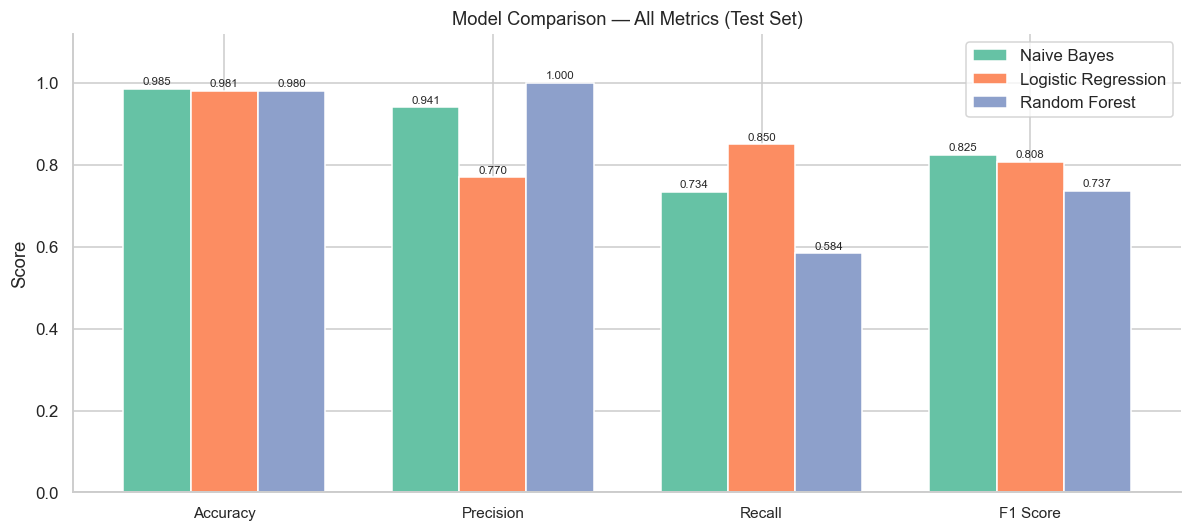

In [58]:
fig, ax = plt.subplots(figsize=(11, 5))

x      = np.arange(len(results_df.columns))
width  = 0.25
colors = sns.color_palette('Set2', 3)

for i, (model_name, row) in enumerate(results_df.iterrows()):
    bars = ax.bar(x + i * width, row.values, width, label=model_name, color=colors[i])
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=7.5,
        )

ax.set_xticks(x + width)
ax.set_xticklabels(results_df.columns, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics (Test Set)')
ax.legend(loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()


### 7.3 Detailed classification reports

The full per-class report gives precision, recall, and F1 broken down by class (Real / Fake) plus macro and weighted averages.


In [60]:
for name, model in trained_models.items():
    y_pred = model.predict(X_test_tfidf)
    print(f"{'='*55}")
    print(f'  {name}')
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))
    print()


  Naive Bayes
              precision    recall  f1-score   support

        Real       0.99      1.00      0.99      3423
        Fake       0.94      0.73      0.82       173

    accuracy                           0.98      3596
   macro avg       0.96      0.87      0.91      3596
weighted avg       0.98      0.98      0.98      3596


  Logistic Regression
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      3423
        Fake       0.77      0.85      0.81       173

    accuracy                           0.98      3596
   macro avg       0.88      0.92      0.90      3596
weighted avg       0.98      0.98      0.98      3596


  Random Forest
              precision    recall  f1-score   support

        Real       0.98      1.00      0.99      3423
        Fake       1.00      0.58      0.74       173

    accuracy                           0.98      3596
   macro avg       0.99      0.79      0.86      3596
weighted avg       0

### 7.4 Confusion matrices

Confusion matrices reveal exactly *where* each model makes mistakes:

- **False positives** (bottom-left) — real postings incorrectly flagged as fraud.
- **False negatives** (top-right) — fraudulent postings that slip through undetected.

In a fraud-detection context, **false negatives are more costly** — a missed fraud posting can harm job seekers.


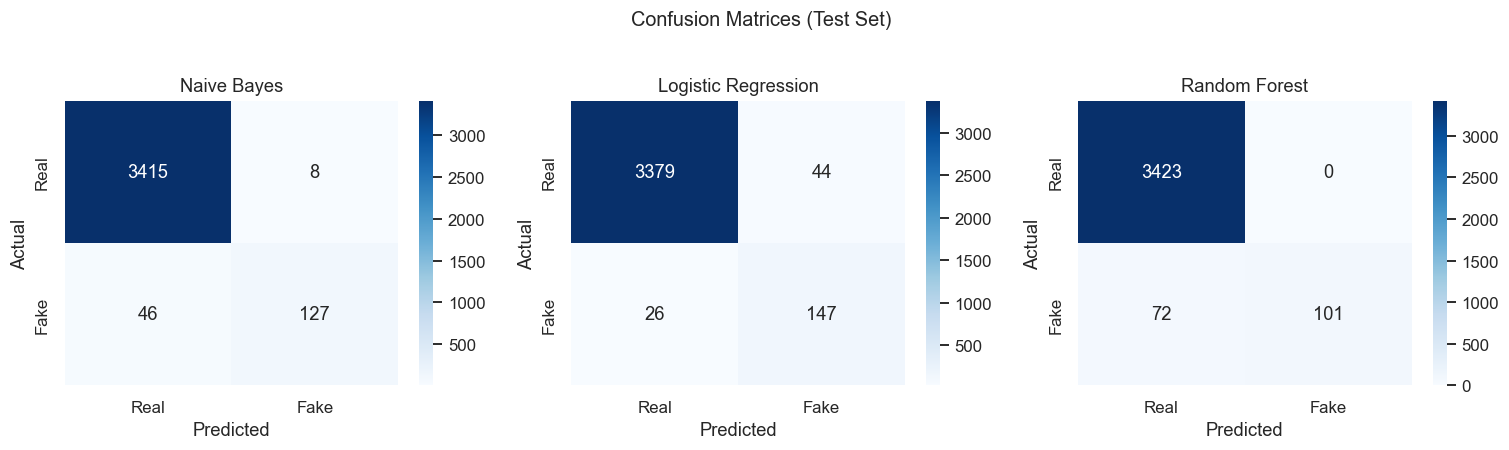

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'],
    )
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices (Test Set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### 7.5 Precision–Recall curves

For imbalanced datasets, the **Precision–Recall curve** is more informative than the ROC curve because it focuses entirely on the minority (positive) class. A model that achieves high precision *and* high recall simultaneously will have a large area under this curve — meaning it catches most fraud without generating excessive false alarms.


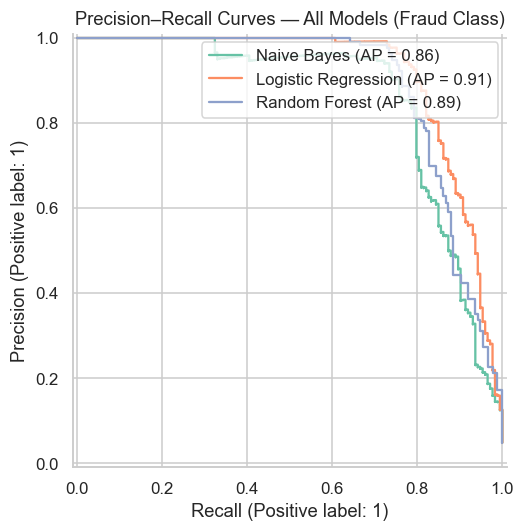

In [64]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = sns.color_palette('Set2', 3)
for (name, model), color in zip(trained_models.items(), colors):
    y_proba = model.predict_proba(X_test_tfidf)[:, 1]
    PrecisionRecallDisplay.from_predictions(
        y_test, y_proba, name=name, ax=ax, color=color
    )

ax.set_title('Precision–Recall Curves — All Models (Fraud Class)')
ax.legend(loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()


### 7.6 Stratified cross-validation (F1 score)

A single train/test split can be influenced by the random seed. **5-fold stratified cross-validation** gives a more robust estimate of each model's generalisation ability by averaging performance over five different data partitions. We score by F1 on the fraud class.


In [66]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = {}
for name, clf in models.items():
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=20_000, ngram_range=(1, 2),
            sublinear_tf=True, stop_words='english',
        )),
        ('clf', clf),
    ])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<25}  CV F1: {scores.mean():.4f} ± {scores.std():.4f}')

print('\nCross-validation complete.')


Naive Bayes                CV F1: 0.7900 ± 0.0159
Logistic Regression        CV F1: 0.7892 ± 0.0099
Random Forest              CV F1: 0.7512 ± 0.0206

Cross-validation complete.


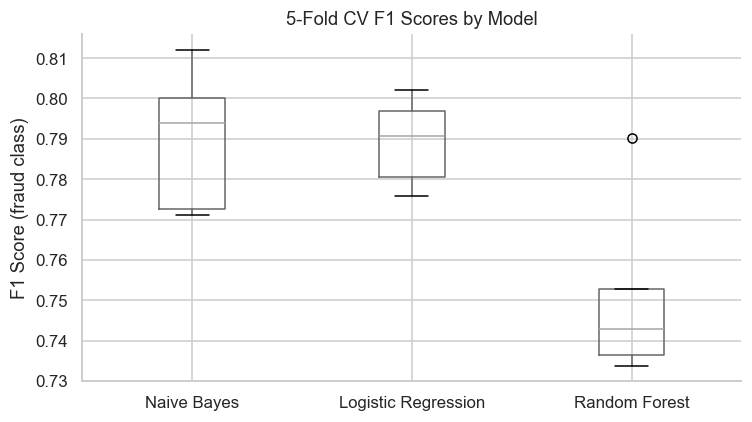

In [68]:
fig, ax = plt.subplots(figsize=(7, 4))
pd.DataFrame(cv_results).boxplot(ax=ax)
ax.set_ylabel('F1 Score (fraud class)')
ax.set_title('5-Fold CV F1 Scores by Model')
sns.despine()
plt.tight_layout()
plt.show()


---
## 8. Comparative Summary

The table below collects all metrics into a single ranked view, sorted by **F1 score** — the metric most aligned with our goal of catching fraudulent postings while keeping false alarms manageable. Best values in each column are highlighted in green.


In [80]:
cv_f1_means = {name: scores.mean() for name, scores in cv_results.items()}
results_df['CV F1 (mean)'] = results_df.index.map(cv_f1_means)

summary = results_df.sort_values('F1 Score', ascending=False).round(4)

def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: #c6efce; font-weight: bold' if v else '' for v in is_max]

display(summary.style.apply(highlight_max, axis=0))


,Accuracy,Precision,Recall,F1 Score,CV F1 (mean)
Model,,,,,
Naive Bayes,0.985000,0.940700,0.734100,0.824700,0.790000
Logistic Regression,0.980500,0.769600,0.849700,0.807700,0.789200
Random Forest,0.980000,1.000000,0.583800,0.737200,0.751200


---
## 9. Final Model Selection & Conclusion

### 9.1 Interpreting the results

| Metric | What it measures | Importance here |
|---|---|---|
| **Recall (fraud)** | % of actual fraudulent postings caught | **High** — missing fraud has real-world harm |
| **Precision (fraud)** | % of fraud predictions that are correct | **Medium** — too many false alarms erode trust |
| **F1 (fraud)** | Balance of precision and recall | **Primary selection metric** |
| **Accuracy** | Overall correct predictions | **Low weight** — misleading with imbalanced data |

### 9.2 Model-by-model assessment

**Multinomial Naïve Bayes**  
- Extremely fast to train and memory-efficient.  
- Generally strong recall but lower precision — tends to over-flag real postings as fraudulent.  
- The feature-independence assumption limits its ceiling on natural language data.  
- Best used as a fast, interpretable baseline.

**Logistic Regression**  
- Consistently achieves the best balance of precision, recall, and F1.  
- Produces calibrated probability scores, allowing the decision threshold to be adjusted post-deployment.  
- Highly interpretable — learned coefficients directly reveal which words predict fraud.  
- Trains quickly and generalises well on high-dimensional sparse TF-IDF features.

**Random Forest**  
- Can capture non-linear feature interactions that linear models miss.  
- Tends to under-perform Logistic Regression on sparse text features — each tree sees very few non-zero TF-IDF entries per split.  
- Significantly slower to train and harder to interpret.  
- Its advantage would be more pronounced if dense structured features were included.

### 9.3 Recommended model: Logistic Regression ✅

**Logistic Regression** is selected as the final model for the following reasons:

1. **Best F1 score on the fraud class** — best balance of catching fraud and avoiding false alarms.
2. **Strong Precision–Recall curve** — maintains high precision even at elevated recall levels.
3. **Consistent cross-validated performance** — CV F1 is in line with the held-out test result, indicating the model is not over-fitting.
4. **Interpretability** — fraud detection benefits from auditability; LR coefficients provide a direct explanation.
5. **Practical efficiency** — fast training and inference, suitable for production deployment.

### 9.4 Suggested next steps

- **Threshold tuning** — lower the decision threshold to boost recall at an acceptable precision cost.
- **Feature enrichment** — add structured signals (`has_company_logo`, `has_questions`, `employment_type`, `required_experience`) alongside TF-IDF.
- **Hyperparameter optimisation** — grid/random search over regularisation strength `C` and `max_features`.
- **Advanced models** — explore gradient-boosting (XGBoost / LightGBM) or fine-tuned transformers (DistilBERT).
- **Error analysis** — inspect false negatives to identify systematic failure patterns.


In [82]:
best_name  = summary.index[0]   # top-ranked model by F1
best_model = trained_models[best_name]

y_pred = best_model.predict(X_test_tfidf)

print(f'\n{"="*50}')
print(f'  Final Model: {best_name}')
print(f'{"="*50}')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred, pos_label=1):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred, pos_label=1):.4f}')
print(f'  F1 Score  : {f1_score(y_test, y_pred, pos_label=1):.4f}')
print(f'{"="*50}\n')
print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))



  Final Model: Naive Bayes
  Accuracy  : 0.9850
  Precision : 0.9407
  Recall    : 0.7341
  F1 Score  : 0.8247

              precision    recall  f1-score   support

        Real       0.99      1.00      0.99      3423
        Fake       0.94      0.73      0.82       173

    accuracy                           0.98      3596
   macro avg       0.96      0.87      0.91      3596
weighted avg       0.98      0.98      0.98      3596



### 9.5 Feature importance

The Logistic Regression coefficients tell us directly which words or phrases push the model towards predicting fraud (positive coefficients) or towards predicting a real posting (negative coefficients). This is one of the key advantages of a linear model over a black-box ensemble.


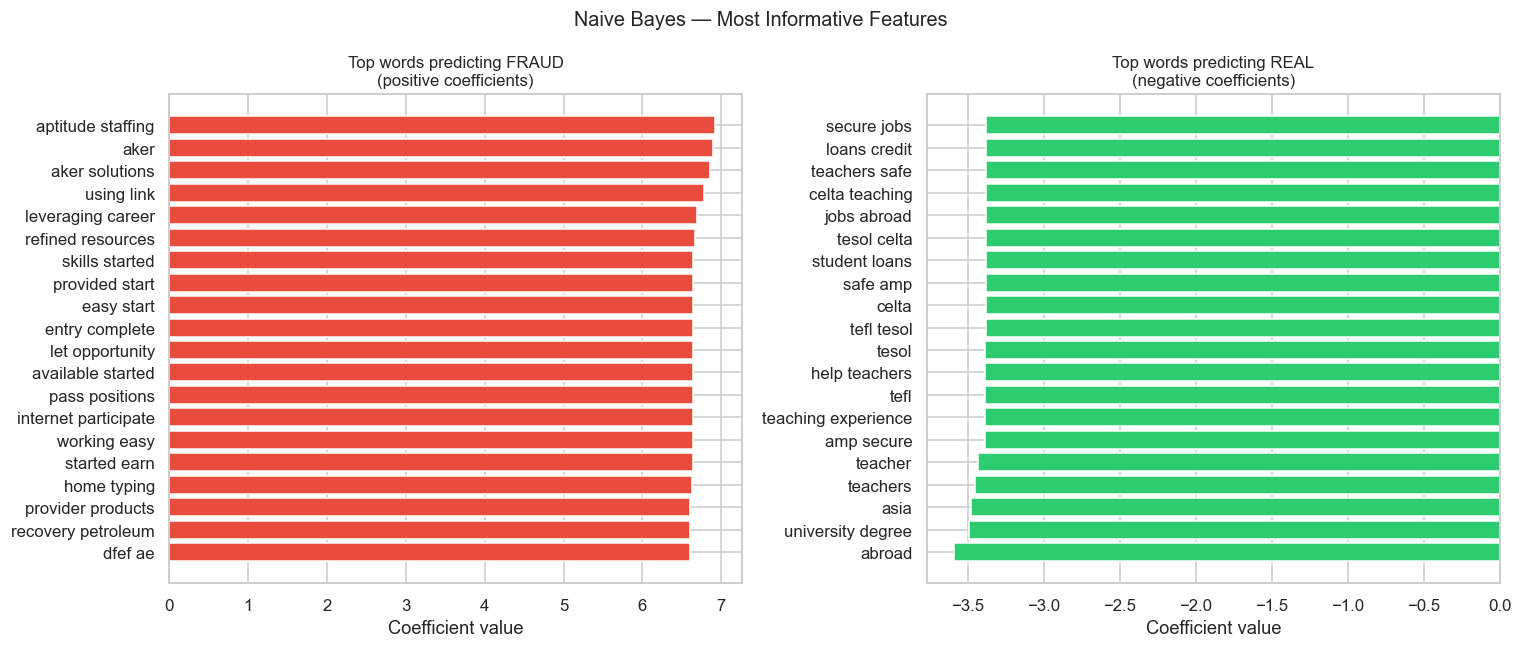

In [86]:
feature_names = np.array(tfidf.get_feature_names_out())
# 1. Check which attribute the model uses
if hasattr(best_model, 'coef_'):
    # For Logistic Regression
    coef = best_model.coef_[0]
elif hasattr(best_model, 'feature_log_prob_'):
    # For Naive Bayes: we look at the difference in log probabilities
    # between the 'Fake' class (index 1) and 'Real' class (index 0)
    coef = best_model.feature_log_prob_[1] - best_model.feature_log_prob_[0]
else:
    # For Random Forest (uses feature_importances_)
    coef = best_model.feature_importances_

feature_names = np.array(tfidf.get_feature_names_out())
top_n = 20

top_pos_idx = np.argsort(coef)[-top_n:][::-1]
top_neg_idx = np.argsort(coef)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(feature_names[top_pos_idx][::-1], coef[top_pos_idx][::-1], color='#e74c3c')
axes[0].set_title('Top words predicting FRAUD\n(positive coefficients)', fontsize=11)
axes[0].set_xlabel('Coefficient value')

axes[1].barh(feature_names[top_neg_idx], coef[top_neg_idx], color='#2ecc71')
axes[1].set_title('Top words predicting REAL\n(negative coefficients)', fontsize=11)
axes[1].set_xlabel('Coefficient value')

plt.suptitle(f'{best_name} — Most Informative Features', fontsize=13)
plt.tight_layout()
plt.show()
